# Notebook for checking Light Scaling outputs
#### Fist we export the needed

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from datetime import datetime, timedelta
import pandas as pd
from uncertainties import ufloat
from astropy.time import Time, TimeGPS
import os, glob, pickle, tables, sys
from scipy.optimize import curve_fit
from scipy.stats import chi2

sys.path.insert(0, os.path.join(os.getcwd(), "../scripts/"))
import geometry as geom
import plotting

# STANDARD paths ---------
root_dl1 = "/fefs/aswg/data/real/DL1/????????/v*/tailcut*/"
root_dl2 = "/fefs/aswg/data/real/DL2/????????/v*/tailcut*/nsb_tuning_*/"

# --- Version --- #
import lstchain
root_lstchain = lstchain.__path__[0]
version_lstchain = f"v{(lstchain.__version__).split('.dev')[0]}"
print(f"Using lstchain version {version_lstchain} from:\n{root_lstchain}")

Using lstchain version v0.10.18 from:
/fefs/aswg/workspace/juan.jimenez/softs/analysis/cta-lstchain/lstchain


In [2]:
source_name = "S241125n"

# Root path of this script
root = os.getcwd() + "/"
root_objects       = os.path.join(root, "objects") # Path to store objects
root_results_final = os.path.join(root_objects, "results_fits_final")

root_data = os.path.join(
    "/fefs/aswg/workspace/juan.jimenez/data/", "real", "mono",
    f"{source_name}", version_lstchain, "GammaDiffuse", "prod_light_scaling"
)

# Intensity parameters
ref_p0 =  1.74 
ref_p1 = -2.23
p0a, p0b, p0c = -0.44751321, 3.62502037, -1.43611437
p1a, p1b, p1c = -2.89253919, 0.99443581, -0.34013068
ref_intensity = 422 # p.e.
lims_intensity = [316, 562]

### Reading the results files

In [3]:
files_results = np.sort(glob.glob(root_results_final + "/*.pkl"))

dict_results = {}
for file_results in files_results:
    with open(file_results, 'rb') as f:
        _dict_ = pickle.load(f)
    dict_results[_dict_["obs_id"]] = _dict_

obs_ids = np.sort(np.array(list(dict_results.keys())))

### Getting some data of the datachecks

In [4]:
%%time
dict_run_sruns, dict_telapsed, dict_tstamp, dict_zd = {}, {}, {}, {}
for obs_id in obs_ids:
    query_dcheck = glob.glob(root_dl1 + f"datacheck/*Run{obs_id}.h5")
    
    if len(query_dcheck) == 0:
        print(f"ERROR: No datacheck found for Run {obs_id}"); sys.exit()
    
    tab = tables.open_file(query_dcheck[0]).root.dl1datacheck.cosmics
    dict_run_sruns[obs_id] = [int(i) for i in tab.col("subrun_index")]
    elapsed_times = tab.col("elapsed_time")
    timestamps = tab.col("dragon_time")
    mean_zd_tel = np.pi / 2 - np.array(tab.col("mean_alt_tel"))
    
    dict_telapsed[obs_id], dict_zd[obs_id], dict_tstamp[obs_id] = {}, {}, {}
    for s, srun in enumerate(dict_run_sruns[obs_id]):
        dict_tstamp[obs_id][srun] = timestamps[s][0]
        dict_telapsed[obs_id][srun] = elapsed_times[s]
        dict_zd[obs_id][srun] = mean_zd_tel[s]
        
    tab.close()

CPU times: user 26.3 s, sys: 10.5 s, total: 36.8 s
Wall time: 1min 43s


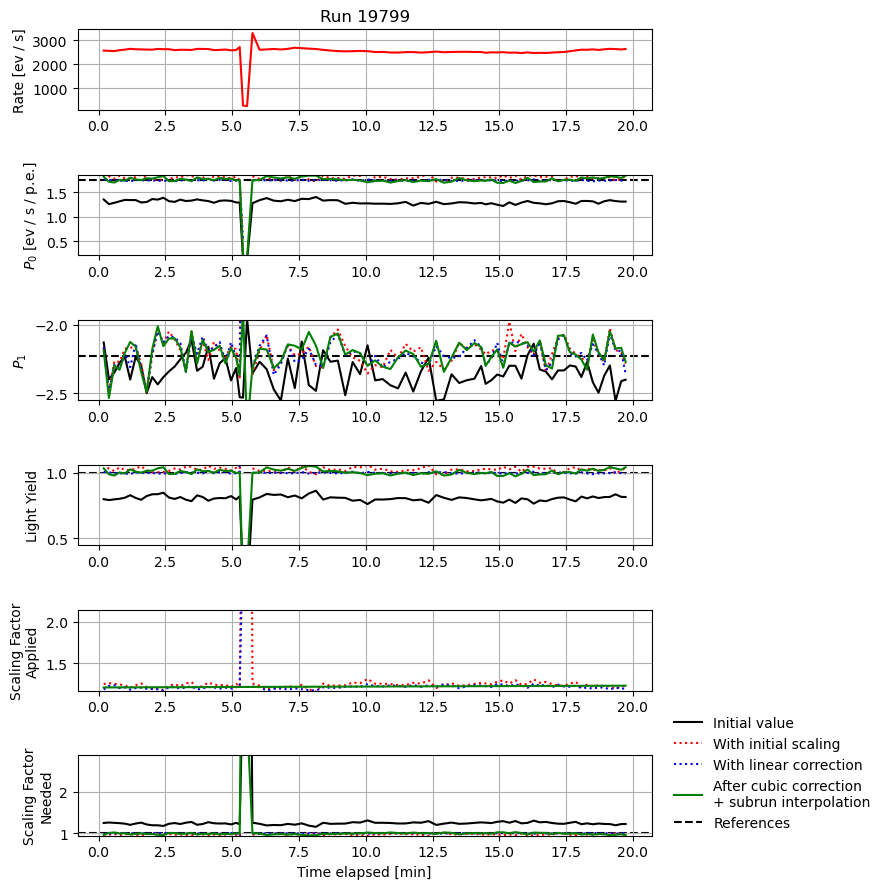

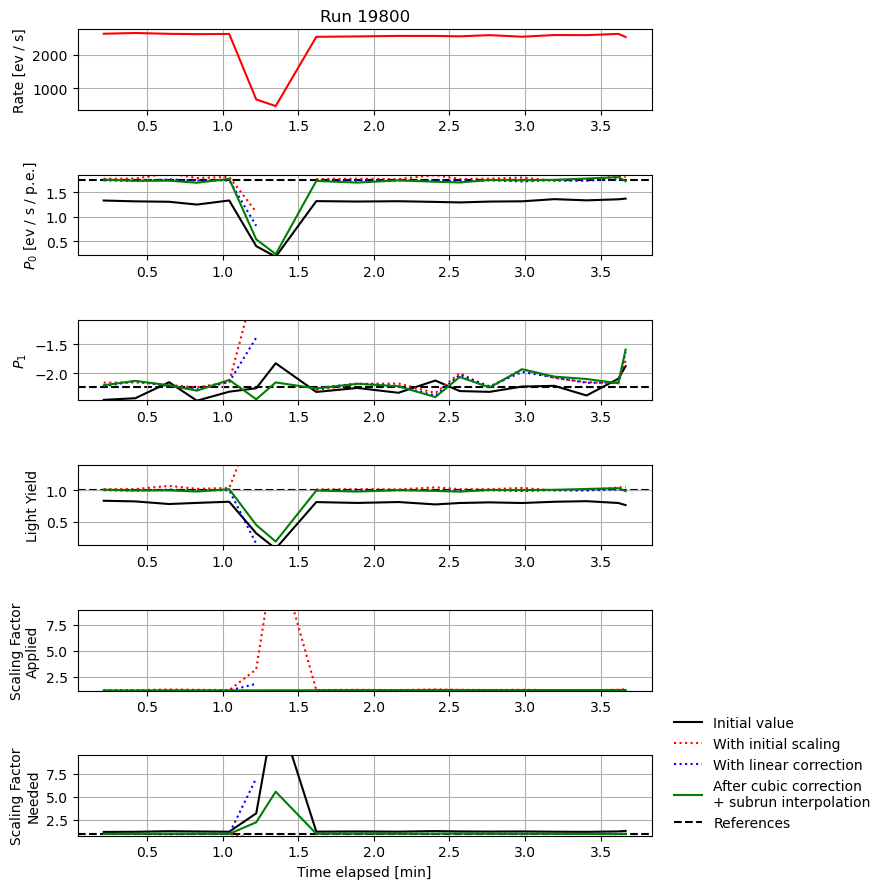

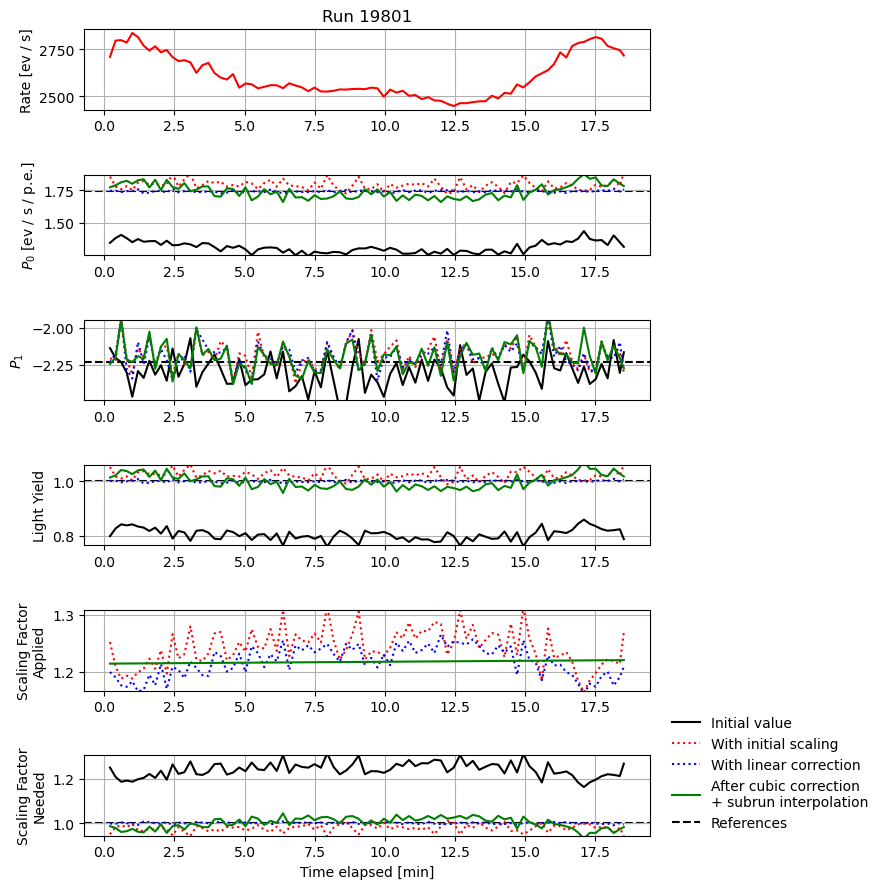

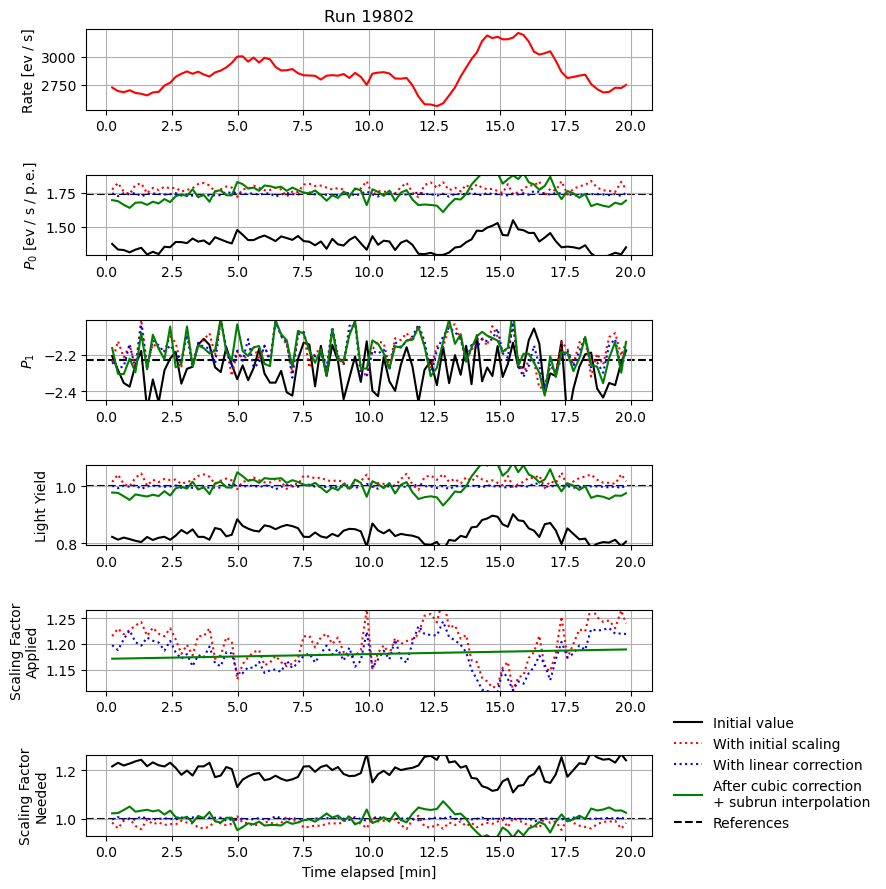

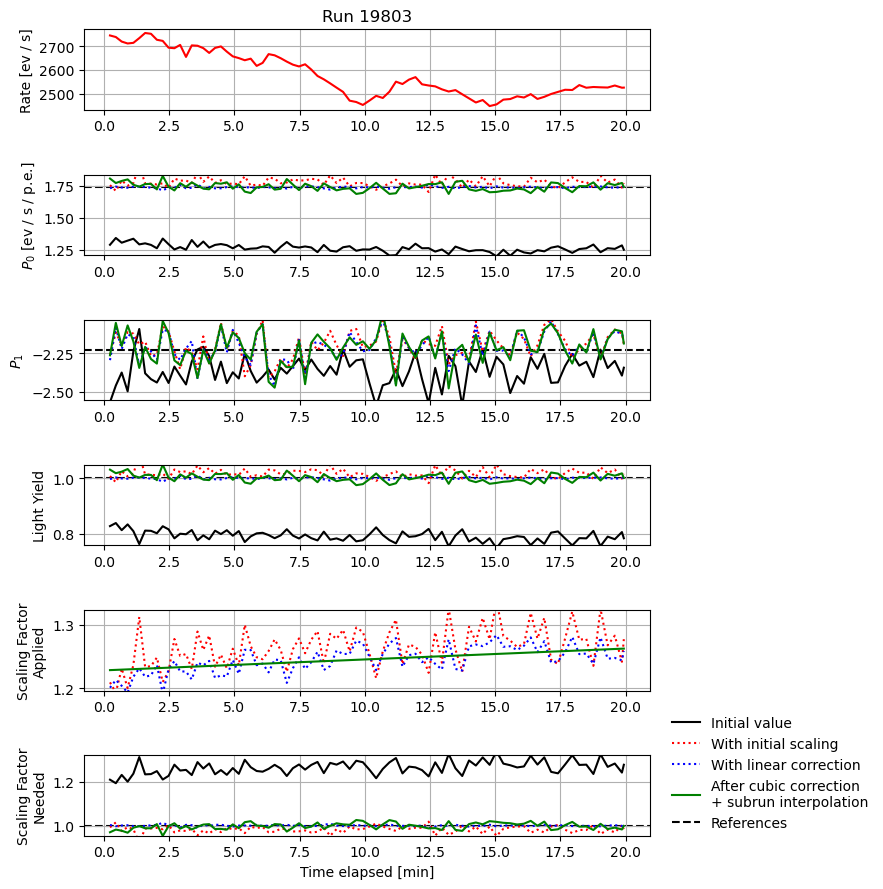

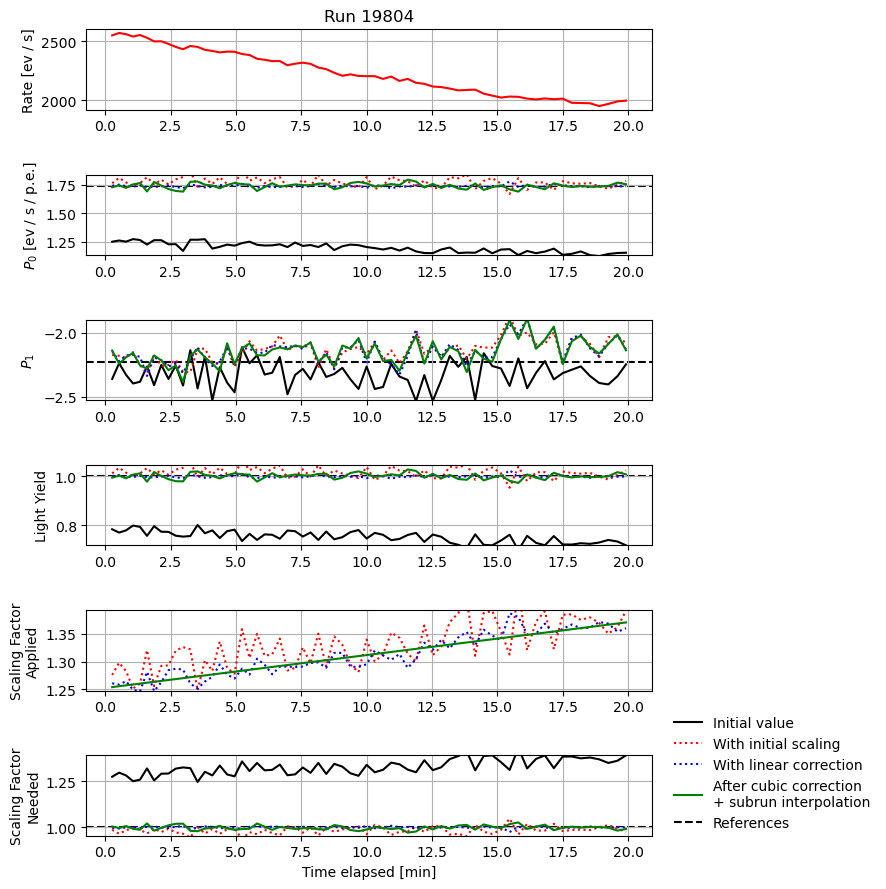

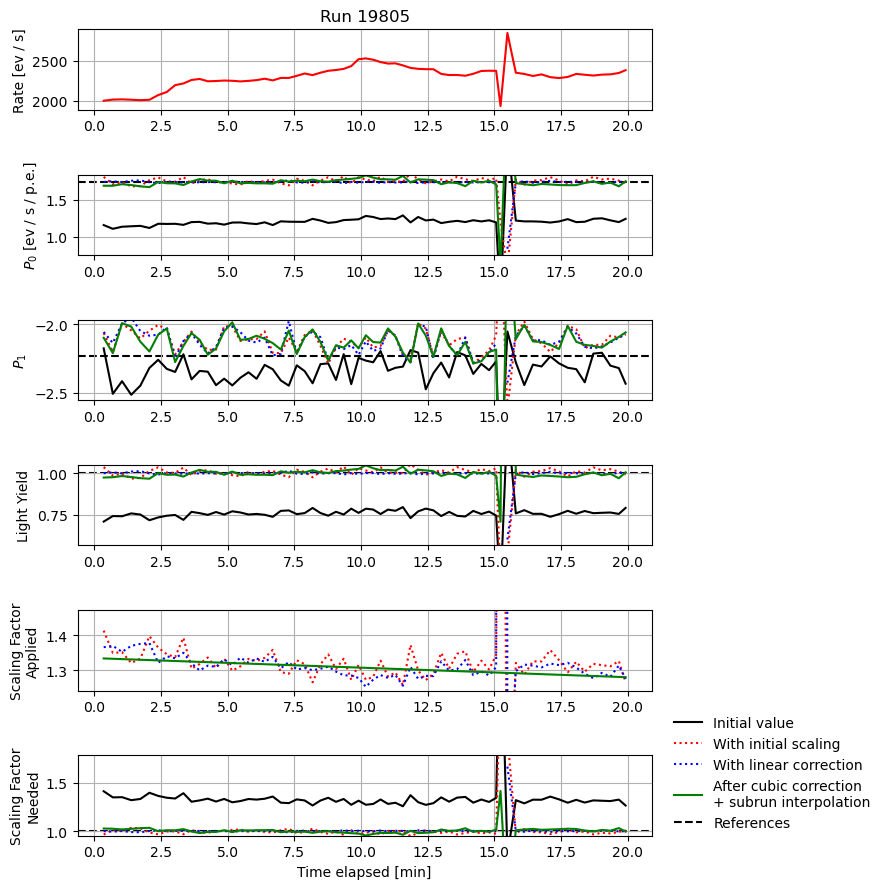

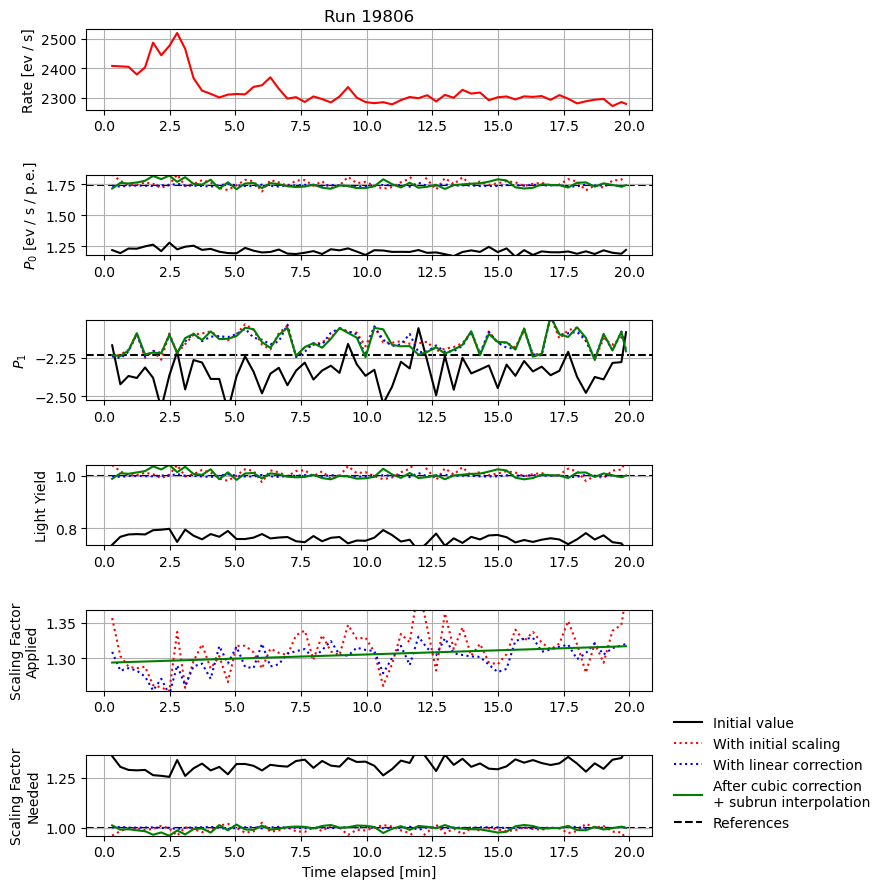

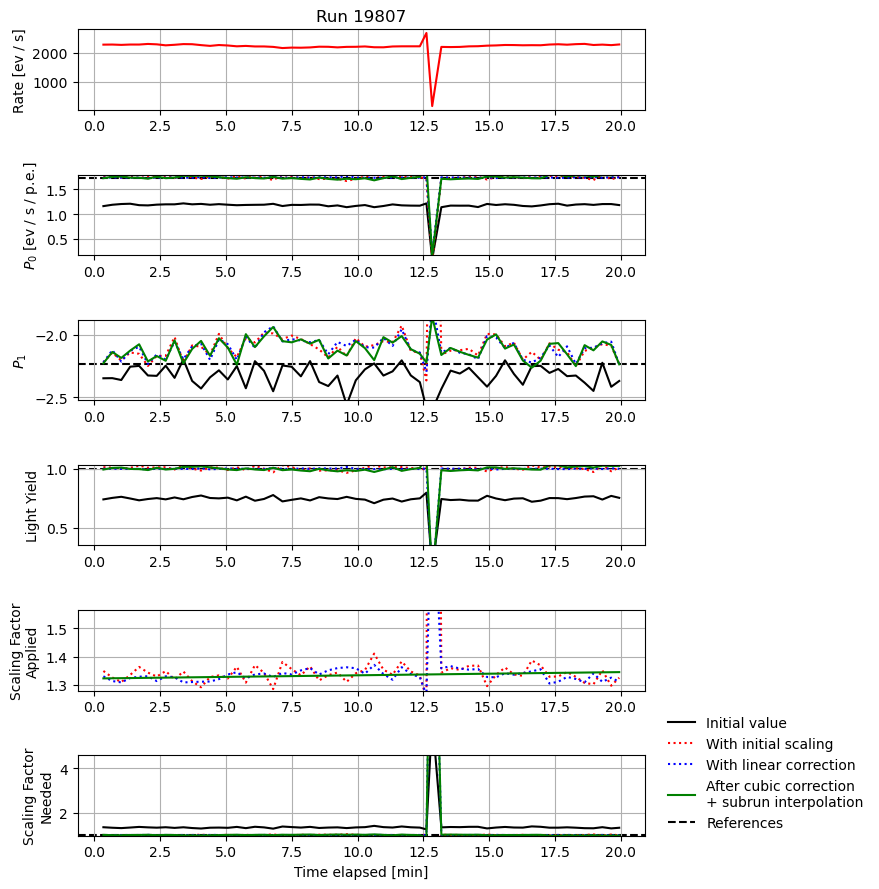

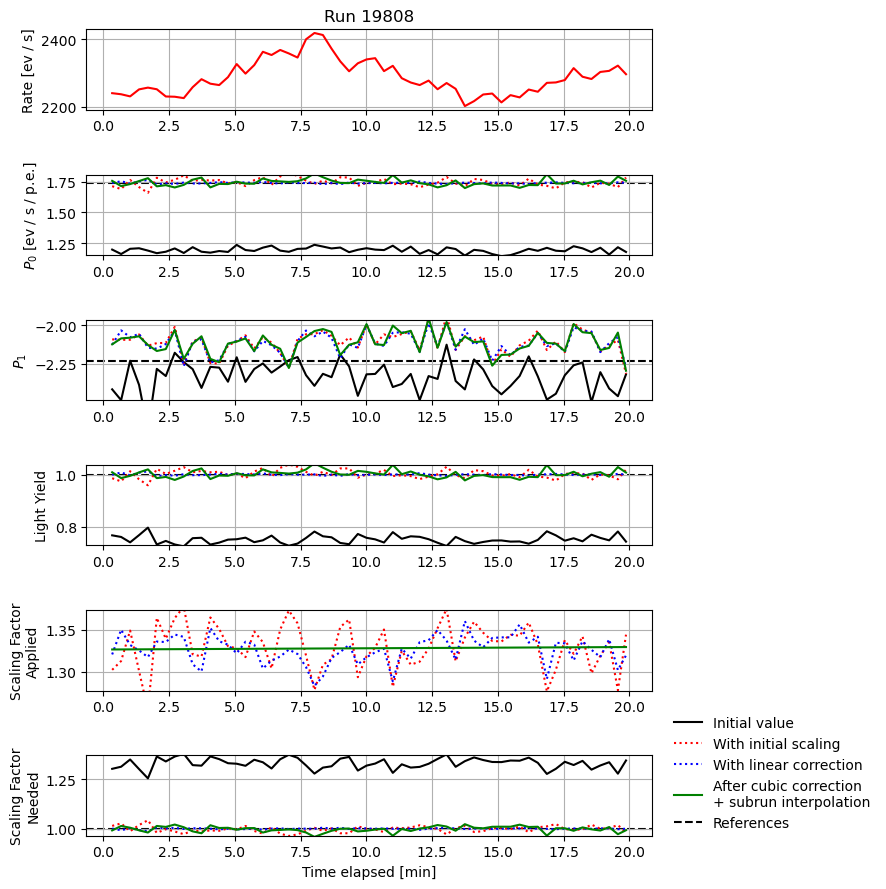

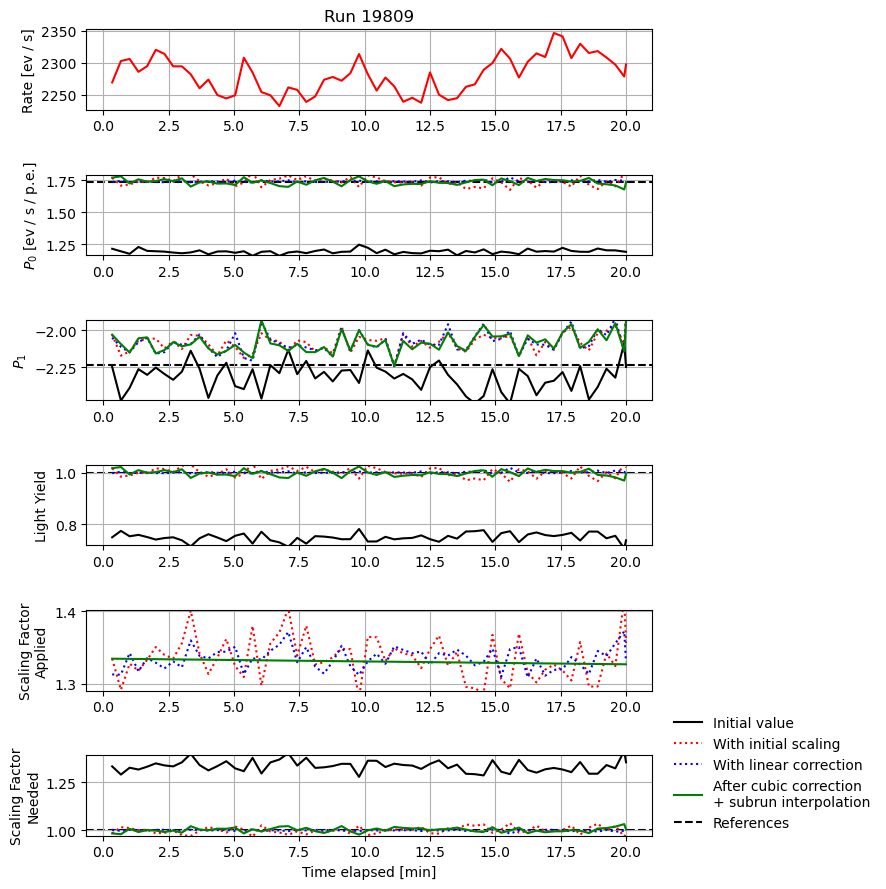

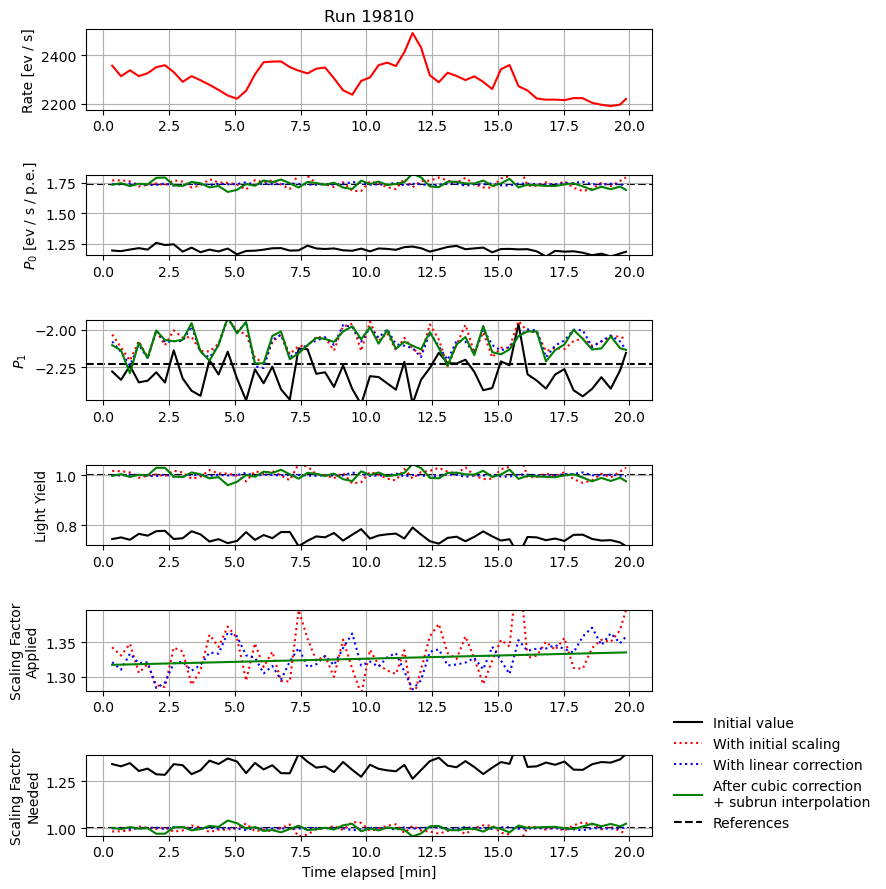

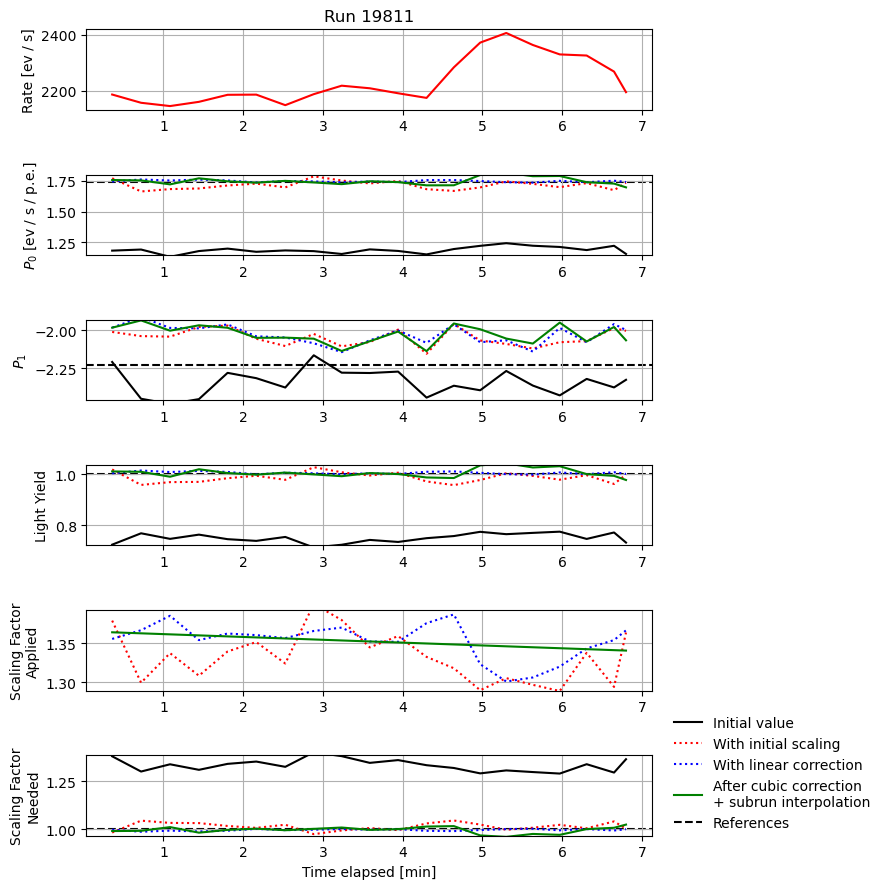

In [5]:
for obs_id in np.sort(list(dict_results.keys()))[:]:
    r = dict_results[obs_id]
    statistics = np.array([r["statistics"][s] for s in np.sort(list(r["statistics"].keys()))])
    tspans = np.array([dict_telapsed[obs_id][s] for s in np.sort(list(dict_telapsed[obs_id].keys()))])

    fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize=(9, 9),)

    ax1.plot(np.cumsum(tspans)/60, statistics/tspans, ls="-", c="r")

    data_p0, data_p1, data_ly, data_s0, data_s1 = [], [], [], [], []
    for j, (iteration_step, l, c, ls) in enumerate(zip(
        ["original", "upper", "linear", "final"], ["Initial value", "With initial scaling", 
         "With linear correction", "After cubic correction\n+ subrun interpolation"],
        ["k", "r", "b", "g"], ["-", ":", ":", "-"],
    )):

        keys = np.sort(list(r["p0"][iteration_step].keys()))
        p0, p1, ly, s0, s1 = (np.array([r[key][iteration_step][s] for s in keys]) 
                              for key in ["p0", "p1", "light_yield", "scaled", "scaling"])

        ax2.plot(np.cumsum(tspans)/60, p0, ls=ls, c=c, label=l); data_p0.extend(p0)
        ax3.plot(np.cumsum(tspans)/60, p1, ls=ls, c=c, label=l); data_p1.extend(p1)
        ax4.plot(np.cumsum(tspans)/60, ly, ls=ls, c=c, label=l); data_ly.extend(ly)
        if iteration_step != "original":
            ax5.plot(np.cumsum(tspans)/60, s0, ls=ls, c=c, label=l); data_s0.extend(s0)
        ax6.plot(np.cumsum(tspans)/60, s1, ls=ls, c=c, label=l); data_s1.extend(s1)

    ax2.axhline(ref_p0, c="k", ls="--", zorder=-10); ax4.axhline(1, c="k", ls="--", zorder=-10)
    ax3.axhline(ref_p1, c="k", ls="--", zorder=-10); ax5.axhline(1, c="k", ls="-", zorder=-10)
    ax6.axhline(1, c="k", ls="--", zorder=-10, label="References")

    for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
        ax.grid()
        
    perc = 1
    for ax, d in zip([ax2, ax3, ax4, ax5, ax6], [data_p0, data_p1, data_ly, data_s0, data_s1]):
        ax.set_ylim(np.nanpercentile(d, perc), np.nanpercentile(d, 100 - perc))

    ax1.set_ylabel("Rate [ev / s]"); ax2.set_ylabel("$P_0$ [ev / s / p.e.]")
    ax3.set_ylabel("$P_1$"); ax4.set_ylabel("Light Yield"); ax6.set_xlabel("Time elapsed [min]")
    ax5.set_ylabel("Scaling Factor\nApplied"); ax6.set_ylabel("Scaling Factor\nNeeded")
    ax1.set_title(f"Run {obs_id}"); ax6.legend(loc=(1.03, 0), frameon=False)
    fig.tight_layout()
#     plt.savefig(f"plots/plot_runwise_ls_parameters_{obs_id}_{source_name}.png", bbox_inches="tight", dpi=300)
    plt.show(); print("\n\n\n")

In [6]:
statistics, time, tspans, ly, sf = [], [], [], [[] for _ in dict_results.keys()], []
p0, p1 = [[] for _ in dict_results.keys()], [[] for _ in dict_results.keys()]
s0, s1 = [[] for _ in dict_results.keys()], [[] for _ in dict_results.keys()]

for i, obs_id in enumerate(np.sort(list(dict_results.keys()))):
    r = dict_results[obs_id]

    statistics.extend(np.array([r["statistics"][s] for s in np.sort(list(r["statistics"].keys()))]))
    tspans.extend([dict_telapsed[obs_id][s] for s in np.sort(list(dict_telapsed[obs_id].keys()))])

    offset = 0 if i == 0 else time[-1]
    time.extend(np.cumsum(
        np.array([dict_telapsed[obs_id][s] for s in np.sort(list(dict_telapsed[obs_id].keys()))])
    ) + offset)
    sf.extend([r["final_scaling"][s] for s in np.sort(list(r["final_scaling"].keys()))])

    for j, iteration_step in enumerate(["original", "upper", "linear", "final"]):
        
        for key, target in zip(["p0", "p1", "light_yield", "scaled", "scaling"], [p0, p1, ly, s0, s1]):
            target[j].extend([r[key][iteration_step][s] for s in sorted(r[key][iteration_step])])
  
        if j ==3:
            xf = [r['scaled'][iteration_step][s] for s in np.sort(list(r['scaling'][iteration_step].keys()))]
            x = ufloat(1 / np.nanmean(xf), np.std(xf) / np.nanmean(xf))
            print(f"Run {obs_id}, Transparency Coefficient = {x}")
        
time0, tspans, statistics, sf = np.array(time), np.array(tspans), np.array(statistics), np.array(sf)
p0, p1, s0, s1, ly = [list(map(np.array, var)) for var in  [p0, p1, s0, s1, ly]]

Run 19799, Transparency Coefficient = 0.820+/-0.005
Run 19800, Transparency Coefficient = 0.822+/-0.011
Run 19801, Transparency Coefficient = 0.8217+/-0.0015
Run 19802, Transparency Coefficient = 0.847+/-0.004
Run 19803, Transparency Coefficient = 0.803+/-0.008
Run 19804, Transparency Coefficient = 0.764+/-0.026
Run 19805, Transparency Coefficient = 0.765+/-0.012
Run 19806, Transparency Coefficient = 0.766+/-0.005
Run 19807, Transparency Coefficient = 0.749+/-0.005
Run 19808, Transparency Coefficient = 0.7530+/-0.0006
Run 19809, Transparency Coefficient = 0.7515+/-0.0017
Run 19810, Transparency Coefficient = 0.754+/-0.004
Run 19811, Transparency Coefficient = 0.740+/-0.005


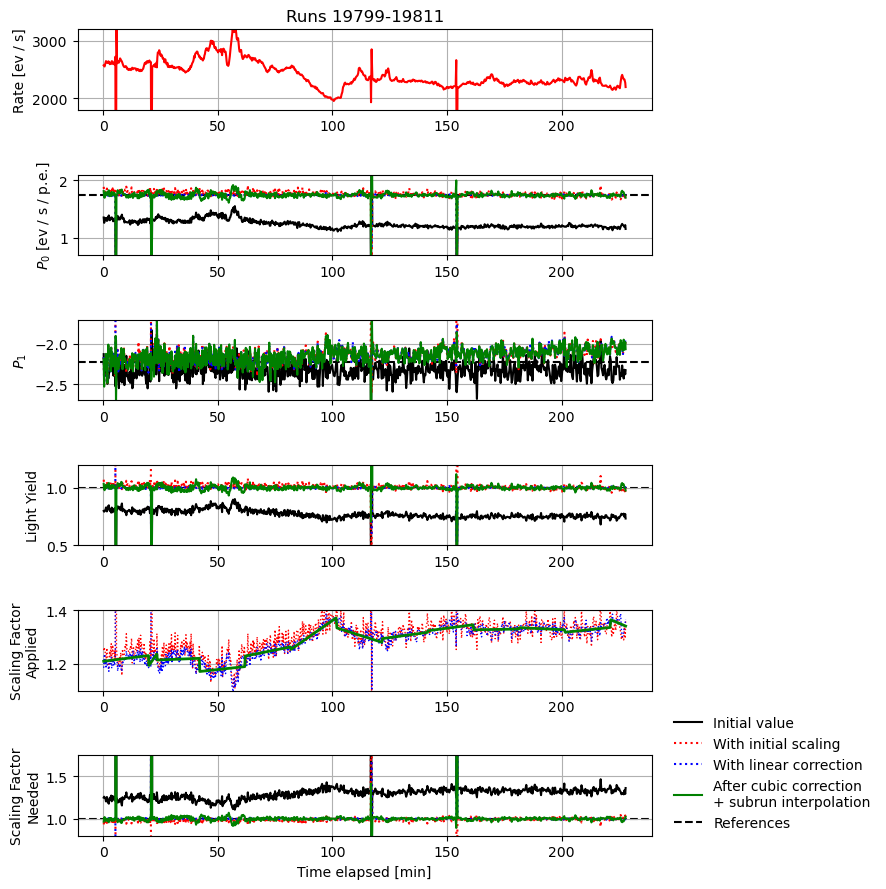

In [7]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(6, 1, figsize=(9, 9),)

ax1.plot(time0/60, statistics/tspans, ls="-", c="r")
# ax5.plot(time0/60, sf, ls=ls, c="k", label=l, lw=1)

for j, (iteration_step, l, c, ls) in enumerate(zip(
    ["original", "upper", "linear", "final"], ["Initial value", "With initial scaling", 
     "With linear correction", "After cubic correction\n+ subrun interpolation"],
    ["k", "r", "b", "g"], ["-", ":", ":", "-"],
)):
    ax2.plot(time0/60, p0[j], ls=ls, c=c, label=l)
    ax3.plot(time0/60, p1[j], ls=ls, c=c, label=l)
    ax4.plot(time0/60, ly[j], ls=ls, c=c, label=l)
    if j != 0:
        ax5.plot(time0/60, s0[j], ls=ls, c=c, label=l, lw=2 if j == 3 else 1)
    ax6.plot(time0/60, s1[j], ls=ls, c=c, label=l)

ax2.axhline(ref_p0, c="k", ls="--", zorder=-10); ax4.axhline(1, c="k", ls="--", zorder=-10)
ax3.axhline(ref_p1, c="k", ls="--", zorder=-10); ax5.axhline(1, c="k", ls="--", zorder=-10)
ax6.axhline(1, c="k", ls="--", zorder=-10, label="References")

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.grid()
ax1.set_ylim(1800, 3200); ax2.set_ylim(0.7, 2.1)
ax3.set_ylim(-2.7, -1.7); ax4.set_ylim(0.5, 1.2)
ax5.set_ylim(1.1, 1.4);  ax6.set_ylim(0.8, 1.75)
ax1.set_ylabel("Rate [ev / s]"); ax2.set_ylabel("$P_0$ [ev / s / p.e.]")
ax3.set_ylabel("$P_1$"); ax4.set_ylabel("Light Yield"); ax6.set_xlabel("Time elapsed [min]")
ax5.set_ylabel("Scaling Factor\nApplied"); ax6.set_ylabel("Scaling Factor\nNeeded")
ax1.set_title(f"Runs {obs_ids[0]}-{obs_ids[-1]}"); ax6.legend(loc=(1.03, 0), frameon=False)
fig.tight_layout()

plt.savefig(f"plots/plot_ls_parameters_{source_name}.png", bbox_inches="tight", dpi=300)
plt.show()

### Transparency coefficient plot + LIDAR data

In [8]:
df = pd.read_csv("../data/LIDAR/S241125n_data.csv")
df = df[df["T@3km"] != -1.0]

lidar_timestamps = Time(df["MJD"], format="mjd").to_datetime()
lidar_telapsed = [0, *np.array([t.total_seconds() for t in np.diff(lidar_timestamps)])]

lidar_zeniths = df["Zd"]
keys = ["T@3km", "T@6km", "T@9km"]
lidar_transmissions = {key: df[key] ** np.cos(np.deg2rad(lidar_zeniths)) for key in keys}
lidar_transmission3, lidar_transmission6, lidar_transmission9 = lidar_transmissions.values()


lidar_offset = lidar_timestamps[0].timestamp() - dict_tstamp[np.sort(list(dict_tstamp.keys()))[0]][0]

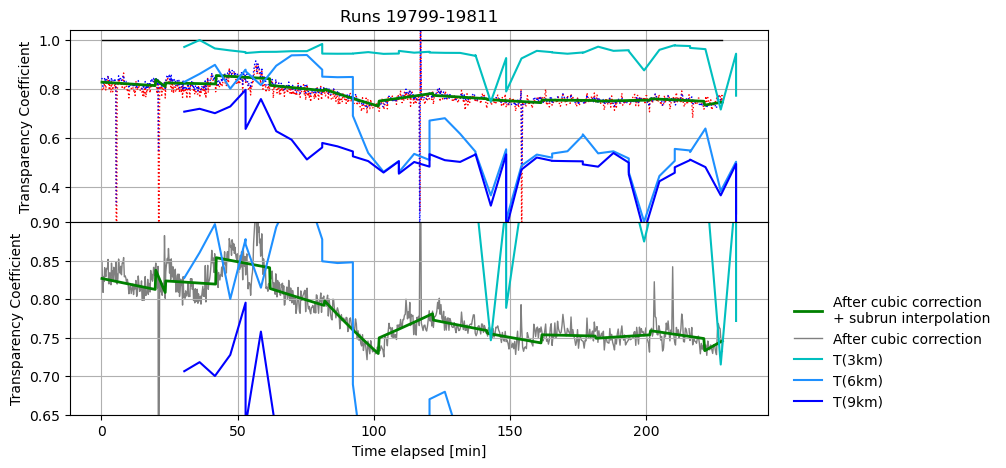

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5),)

for j, (iteration_step, l, c, ls) in enumerate(zip(
    ["original", "upper", "linear", "final"], ["Initial value", "With initial scaling", 
     "With linear correction", "After cubic correction\n+ subrun interpolation"],
    ["k", "r", "b", "g"], ["-", ":", ":", "-"],
)):
    ax1.plot(time0/60, 1 / s0[j], ls=ls, c=c, label=l, lw=2 if j == 3 else 1)
    ax2.plot(time0/60, 1 / s0[j], ls=ls, c=c, label=l, lw=2 if j == 3 else 1) if j ==3 else None
        
ax2.plot(time0/60, 1 / sf, ls=ls, c="gray", label="After cubic correction", lw=1, zorder=-1)

for ax in [ax1, ax2]:
    ax.grid(); ax.set_ylabel("Transparency Coefficient")

    labels = ["T(3km)", "T(6km)", "T(9km)"]
    transmissions = [lidar_transmission3, lidar_transmission6, lidar_transmission9]
    x_values = np.cumsum(lidar_telapsed) / 60 + lidar_offset / 60
    for color, label, transmission in zip(["c", "dodgerblue", "b"], labels, transmissions):
        ax.plot(x_values, transmission, "-", mew=1.5, ms=6, c=color, label=label)

ax1.set_ylim(1/1.8-0.3, 1/1.35+0.3); ax2.set_ylim(0.65, 0.9)
ax2.legend(loc=(1.03, 0), frameon=False); ax1.set_title(f"Runs {obs_ids[0]}-{obs_ids[-1]}")
plt.subplots_adjust(wspace=0, hspace=0); ax2.set_xlabel("Time elapsed [min]")

plt.savefig(f"plots/plot_transparency_{source_name}.png", bbox_inches="tight", dpi=300)
plt.show()

### Run wise Intensity comparison

In [10]:
%%time
bin_edges = np.logspace(1, 6, 101)
bin_c = (bin_edges[1:] + bin_edges[:-1]) / 2
bin_w = np.diff(bin_edges)
mask_dcheck_bins_fit = ((bin_c >= lims_intensity[0]) & (bin_c <= lims_intensity[1]))

rates, rates_c = [], []
ly, ly_c, u_ly, u_ly_c = [], [], [], []
p0, p0_c, u_p0, u_p0_c = [], [], [], []
p1, p1_c, u_p1, u_p1_c = [], [], [], []

for j, obs_id in enumerate(obs_ids):
    print(f"Computing intensity parameters for Run {obs_ids[j]}, {j+1} / {len(obs_ids)}")
    
    file = np.sort(glob.glob(os.path.join(root_dl1, f"dl1_LST-1.Run{obs_id}.h5")))[0]
    file_c = np.sort(glob.glob(os.path.join(
        root_data, "DL1", f"dl1_LST-1.Run{obs_id}.h5"))
    )[0]

    tab   = tables.open_file(file).root.dl1.event.telescope.parameters.LST_LSTCam
    tab_c = tables.open_file(file_c).root.dl1.event.telescope.parameters.LST_LSTCam
    _intensity_srun,   _ = np.histogram(tab.col("intensity"), bins = bin_edges)
    _intensity_srun_c, _ = np.histogram(tab_c.col("intensity"), bins = bin_edges)
    tab.close(); tab_c.close()
    
    tlapsed_run = np.sum([dict_telapsed[obs_id][s] for s in dict_telapsed[obs_id].keys()])
    zd_run = np.mean([dict_zd[obs_id][s] for s in dict_zd[obs_id].keys()])
    
    _rates     = _intensity_srun   / tlapsed_run / bin_w
    _rates_c   = _intensity_srun_c / tlapsed_run / bin_w
    _u_rates   = np.sqrt(_intensity_srun)   / tlapsed_run / bin_w
    _u_rates_c = np.sqrt(_intensity_srun_c) / tlapsed_run / bin_w

    x_fit = bin_c[mask_dcheck_bins_fit] / ref_intensity

    def get_ly(x_fit, y_fit, yerr_fit):
        params, pcov, info, _, _ = curve_fit(
            f     = geom.powerlaw,
            xdata = x_fit,
            ydata = y_fit,
            sigma = yerr_fit,
            p0    = [ref_p0, ref_p1],
            full_output = True,
        )

        _p0, _p1 = params
        _u_p0, _u_p1 = np.sqrt(pcov[0, 0]), np.sqrt(pcov[1, 1])
        _chi2, _ndf = np.sum(info["fvec"] ** 2), sum(mask_dcheck_bins_fit)

        # Then we correct by zenith
        corr_factor_p0 = geom.pol2(1, p0a, p0b, p0c) / geom.pol2(np.cos(zd_run), p0a, p0b, p0c)
        corr_factor_p1 = geom.pol2(1, p1a, p1b, p1c) - geom.pol2(np.cos(zd_run), p1a, p1b, p1c)   

        _p0_c,   _p1_c   = _p0   * corr_factor_p0, _p1 + corr_factor_p1
        _u_p0_c, _u_p1_c = _u_p0 * corr_factor_p0, _u_p1

        # Getting the Light Yield
        _ly, _u_ly = geom.calc_light_yield(
            p0_fit = _p0_c,
            p1_fit = _p1_c, 
            sigma_p0_fit = _u_p0_c, 
            sigma_p1_fit = _u_p1_c, 
            p0_ref = ref_p0,
        )
        return _p0_c, _u_p0_c, _p1_c, _u_p1_c, _chi2, _ndf, _ly, _u_ly
    
    _p0, _u_p0, _p1, _u_p1, _chi2, _ndf, _ly, _u_ly = get_ly(
        x_fit, 
        y_fit = _rates[mask_dcheck_bins_fit],
        yerr_fit = _u_rates[mask_dcheck_bins_fit],
    )
    _p0_c, _u_p0_c, _p1_c, _u_p1_c, _chi2_c, _ndf_c, _ly_c, _u_ly_c = get_ly(
        x_fit, 
        y_fit = _rates_c[mask_dcheck_bins_fit],
        yerr_fit = _u_rates_c[mask_dcheck_bins_fit],
    )
    rates.append(_rates); rates_c.append(_rates_c)
    p0.append(_p0); u_p0.append(_u_p0)
    p1.append(_p1); u_p1.append(_u_p1)
    p0_c.append(_p0_c); u_p0_c.append(_u_p0_c)
    p1_c.append(_p1_c); u_p1_c.append(_u_p1_c)
    ly.append(_ly); u_ly.append(_u_ly)
    ly_c.append(_ly_c); u_ly_c.append(_u_ly_c)


Computing intensity parameters for Run 19799, 1 / 13
Computing intensity parameters for Run 19800, 2 / 13
Computing intensity parameters for Run 19801, 3 / 13
Computing intensity parameters for Run 19802, 4 / 13
Computing intensity parameters for Run 19803, 5 / 13
Computing intensity parameters for Run 19804, 6 / 13
Computing intensity parameters for Run 19805, 7 / 13
Computing intensity parameters for Run 19806, 8 / 13
Computing intensity parameters for Run 19807, 9 / 13
Computing intensity parameters for Run 19808, 10 / 13
Computing intensity parameters for Run 19809, 11 / 13
Computing intensity parameters for Run 19810, 12 / 13
Computing intensity parameters for Run 19811, 13 / 13
CPU times: user 1min 33s, sys: 43.4 s, total: 2min 16s
Wall time: 7min 44s


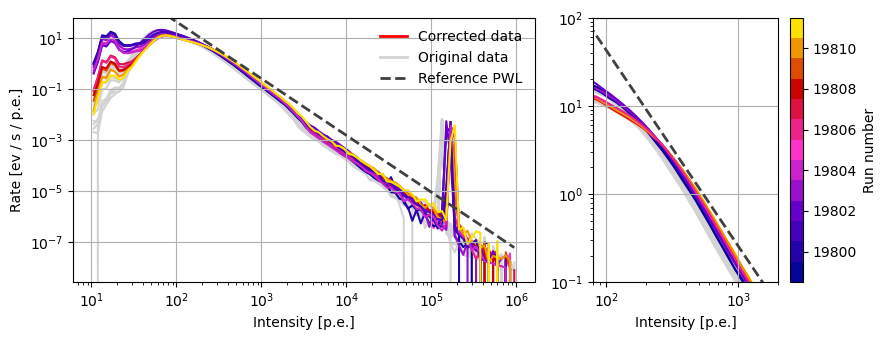

In [11]:
runs_total = range(len(obs_ids))
_, colors_run = plotting.get_cmap_colors(runs_total, plotting.default_cmap)
  
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5), gridspec_kw={"width_ratios": [2, 1]})
 
for i in range(len(rates)):
    for ax in [ax1, ax2]:
        ax.plot(bin_c, rates_c[i], c=colors_run[i], zorder=np.random.rand())
        ax.plot(bin_c, rates[i], c="lightgray", zorder=-10)

x = bin_c
y = geom.powerlaw(x / ref_intensity, ref_p0, ref_p1)

if len(obs_ids) > 1:
    disc_cmap = plotting.create_discrete_cmap_from_colors(len(obs_ids))
    plotting.plot_colorbar(fig, ax2, obs_ids, disc_cmap, "Run number", True, False)
ax1.set_ylabel("Rate [ev / s / p.e.]")
ax1.plot([], [], c="r", ls="-", lw=2, label="Corrected data")
ax1.plot([], [], c="lightgray", ls="-", lw=2, label="Original data")

for ax in [ax1, ax2]:
    ax.loglog()
    ylims = ax.get_ylim()
    ax.plot(x, y, c="0.25", ls="--", lw=2, label="Reference PWL")
    ax.set_ylim(ylims)

    ax.set_xlabel("Intensity [p.e.]"); 
    ax.grid()
ax1.legend(loc=1, frameon=False)
ax2.set_xlim(80, 2000); ax2.set_ylim(0.1, 100)
fig.tight_layout()

plt.savefig(root + f"plots/plot_comparison_intensity_spectrums_{source_name}.png", bbox_inches="tight", dpi=300)
plt.show()

### Showing the Light Yield and P0 values

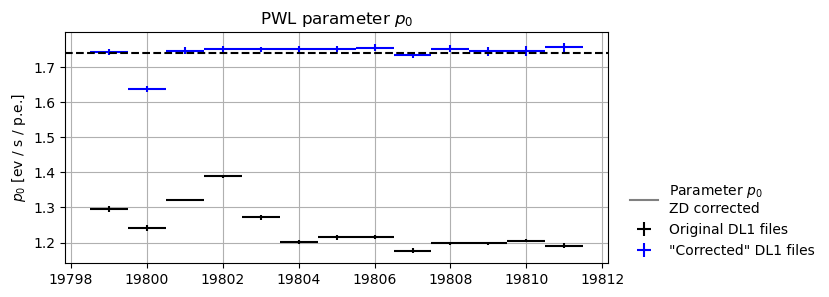

In [12]:
fig, ax = plt.subplots(figsize=(7, 3))

ax.errorbar(obs_ids, p0, yerr=u_p0, xerr=0.5, ls="", c="k", label="Original DL1 files")
ax.errorbar(obs_ids, p0_c, yerr=u_p0_c, xerr=0.5, ls="", c="b", label="\"Corrected\" DL1 files")

ax.axhline(ref_p0, c="k", ls="--")
ax.plot([], [], "-", color="gray", label="Parameter $p_0$\nZD corrected")

ax.grid(); ax.set_ylabel("$p_0$ [ev / s / p.e.]"); ax.legend(loc=(1.03, 0), frameon=False)
ax.tick_params(axis="x", labelrotation=0); ax.set_title("PWL parameter $p_0$")

plt.savefig(root + f"plots/plot_comparison_p0_{source_name}.png", bbox_inches="tight", dpi=300)
plt.show()

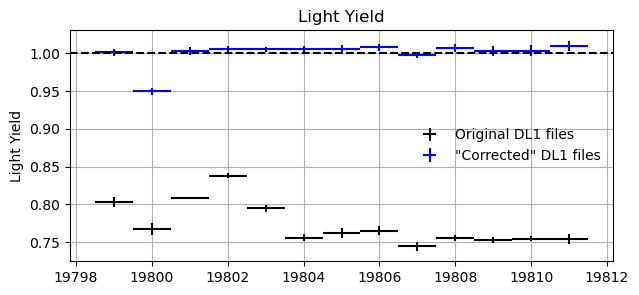

In [13]:
fig, ax = plt.subplots(figsize=(7, 3))

ax.errorbar(obs_ids, ly, yerr=u_ly, xerr=0.5, ls="", c="k", label="Original DL1 files")
ax.errorbar(obs_ids, ly_c, yerr=u_ly_c, xerr=0.5, ls="", c="b", label="\"Corrected\" DL1 files")

ax.axhline(1, c="k", ls="--")

ax.grid(); ax.set_ylabel("Light Yield"); ax.legend(frameon=False)
ax.tick_params(axis="x", labelrotation=0); ax.set_title("Light Yield")

plt.savefig(root + f"plots/plot_comparison_ly_{source_name}.png", bbox_inches="tight", dpi=300)
plt.show()

## Checks of DL2 data

In [14]:
dict_hist = {
    "intensity":{
        "bins": np.logspace(1, 6, 100)
    },
    "width":{
        "bins": np.linspace(0, 1.5, 100)
    },  
    "length":{
        "bins": np.linspace(0, 2, 100)
    },
    "time_gradient":{
        "bins": np.linspace(-320, 320, 100)
    },
    "n_pixels":{
        "bins": np.arange(0, 1000, 15)
    },
    "gammaness":{
        "bins": np.linspace(0, 1, 100)
    },
    "reco_energy":{
        "bins": np.logspace(-1.5, 2.5, 100)
    },
}

In [15]:
%%time
data_dict = {
    "intensity":     [np.array([]) for _ in range(4)],
#     "length":        [np.array([]) for _ in range(4)],
#     "width":         [np.array([]) for _ in range(4)],
    "time_gradient": [np.array([]) for _ in range(4)],
    "n_pixels":      [np.array([]) for _ in range(4)],
    "gammaness":     [np.array([]) for _ in range(4)],
    "reco_energy":   [np.array([]) for _ in range(4)],
    "event_id":      [np.array([]) for _ in range(3)],
}

for i, obs_id in enumerate(obs_ids):
    print(f"{'-' * 60}\nReading DL2 for Run {obs_id}, {i+1} / {len(obs_ids)}")
    
    file_dl2 = [
        glob.glob(os.path.join(root_dl2, f"dl2_LST-1.Run{obs_id:05}.h5"))[0],
        os.path.join(root_data, "DL2", f"dl2_LST-1.Run{obs_id:05}.h5")
    ]
    
    tabs = [tables.open_file(f).root.dl2.event.telescope.parameters.LST_LSTCam for f in file_dl2]
    
    event_ids = [tab.col("event_id") for tab in tabs]

    mask_cosmics = [np.array(t.col("event_type")) == 32 for t in tabs]
    
#     mask0_gamma =  tabs[0].col("gammaness") >= 0.0
#     mask1_intensity = tabs[0].col("intensity") >= 0.0
    
    masks_filters = [mask_cosmics[0], mask_cosmics[1]] # & mask0_gamma
    
    event_id_intersection = np.intersect1d(
        event_ids[0][masks_filters[0]], event_ids[1][masks_filters[1]] 
    )
    masks = [np.isin(event_ids[j], event_id_intersection) for j in range(2)]
    exclusive_masks = [
        masks_filters[j] & ~np.isin(event_ids[j], event_id_intersection)
        for j in range(2)
    ]
    
    for key in data_dict.keys():
        if key == "event_id":
            data_dict[key][0] = np.concatenate((data_dict[key][0], event_ids[0][masks_filters[0]]))
            data_dict[key][1] = np.concatenate((data_dict[key][1], event_ids[1][masks_filters[1]]))
            data_dict[key][2] = np.concatenate((data_dict[key][2], event_id_intersection))
        else:
            cols = [tab.col(key) for tab in tabs]
            for j in range(2):
                data_dict[key][j]   = np.concatenate((data_dict[key][j],   cols[j][exclusive_masks[j]]))
                data_dict[key][j+2] = np.concatenate((data_dict[key][j+2], cols[j][masks[j]]))
    
    print(f"N of events:\n - Original data  {len(event_ids[0])}\n - Corrected data {len(event_ids[1])}")
    print(f"{(len(event_ids[1])-len(event_ids[0])) / len(event_ids[0]) * 100:+.2f}%")
event_array = [np.arange(len(d)) for d in data_dict["intensity"]]

------------------------------------------------------------
Reading DL2 for Run 19799, 1 / 13
N of events:
 - Original data  2993239
 - Corrected data 3142943
+5.00%
------------------------------------------------------------
Reading DL2 for Run 19800, 2 / 13
N of events:
 - Original data  529496
 - Corrected data 557778
+5.34%
------------------------------------------------------------
Reading DL2 for Run 19801, 3 / 13
N of events:
 - Original data  2881475
 - Corrected data 3022592
+4.90%
------------------------------------------------------------
Reading DL2 for Run 19802, 4 / 13
N of events:
 - Original data  3377457
 - Corrected data 3487874
+3.27%
------------------------------------------------------------
Reading DL2 for Run 19803, 5 / 13
N of events:
 - Original data  3069474
 - Corrected data 3242190
+5.63%
------------------------------------------------------------
Reading DL2 for Run 19804, 6 / 13
N of events:
 - Original data  2650652
 - Corrected data 2839029
+7.11%


Total (event_type == 32)


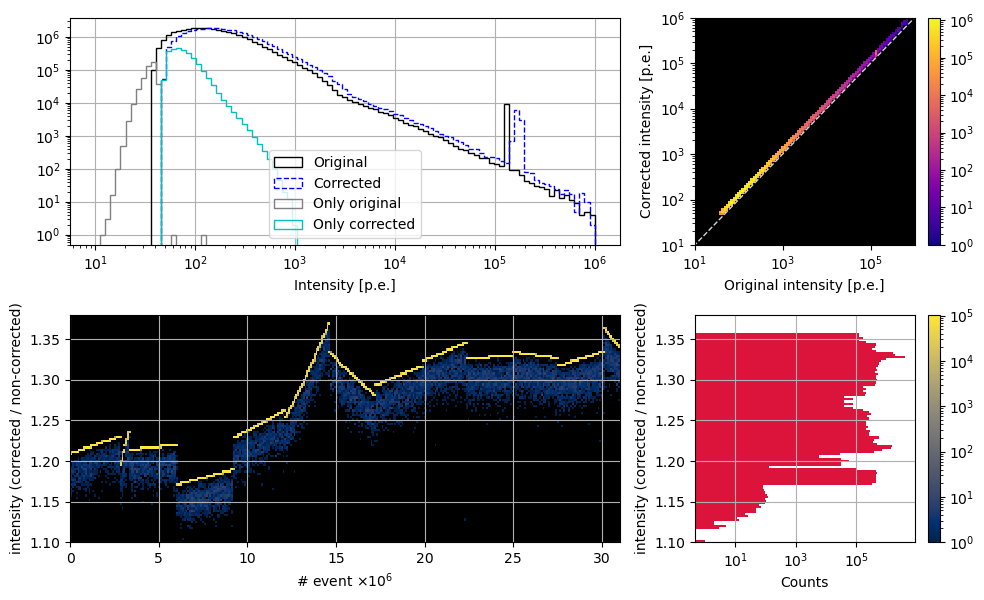

In [16]:
print("Total (event_type == 32)")
fig, axs = plt.subplots(2, 2, figsize=(10, 6.1), gridspec_kw={"width_ratios": [2, 1]})

key = "intensity"
axs[0,0].hist(data_dict[key][2], bins=dict_hist[key]["bins"], 
         color="k", label="Original", histtype="step")
axs[0,0].hist(data_dict[key][3], bins=dict_hist[key]["bins"], 
         color="b", ls="--", label="Corrected", histtype="step")
axs[0,0].hist(data_dict[key][0], bins=dict_hist[key]["bins"], 
         color="grey", histtype="step", label="Only original")
axs[0,0].hist(data_dict[key][1], bins=dict_hist[key]["bins"], 
         color="c", histtype="step", label="Only corrected")

histR = axs[0,1].hist2d(data_dict[key][2], data_dict[key][3], bins=dict_hist[key]["bins"], 
                  norm=LogNorm(), cmap="plasma")
fig.colorbar(histR[3], ax=axs[0,1], label="")

histE = axs[1,0].hist2d(event_array[2] * 1e-6, (data_dict[key][3] / data_dict[key][2]), 
         bins=(300, 100), norm=LogNorm(), cmap="cividis")
fig.colorbar(histE[3], ax=axs[1,1], label="")
axs[1,1].hist((data_dict[key][3] / data_dict[key][2]), orientation="horizontal",
         bins=np.linspace(1.1, 1.358, 100), histtype="stepfilled", color="crimson")

axs[0,1].plot([-1e10, 1e10], [-1e10, 1e10], ls="--", lw=1, c="lightgray")

for ax in axs[0]:
    ax.loglog()
for ax in axs[1]:
    ax.grid(); ax.set_ylim(1.1, 1.38); ax.set_ylabel("intensity (corrected / non-corrected)")
    
axs[0,0].set_xlabel("Intensity [p.e.]"); axs[0,0].legend(loc=8); axs[0,0].grid()
axs[0,1].set_xlabel("Original intensity [p.e.]"); axs[0,1].set_ylabel("Corrected intensity [p.e.]")
axs[0,1].set_facecolor("k"); axs[1,0].set_facecolor("k"); axs[1,1].set_xscale("log")
axs[1,0].set_xlabel("# event $\\times 10^6$"); axs[1,1].set_xlabel("Counts")
fig.tight_layout()

plt.savefig(root + f"plots/plot_comparison_intensity_{source_name}.png", bbox_inches="tight", dpi=300)
plt.show()

event_type == 32 & gammaness > 0.8


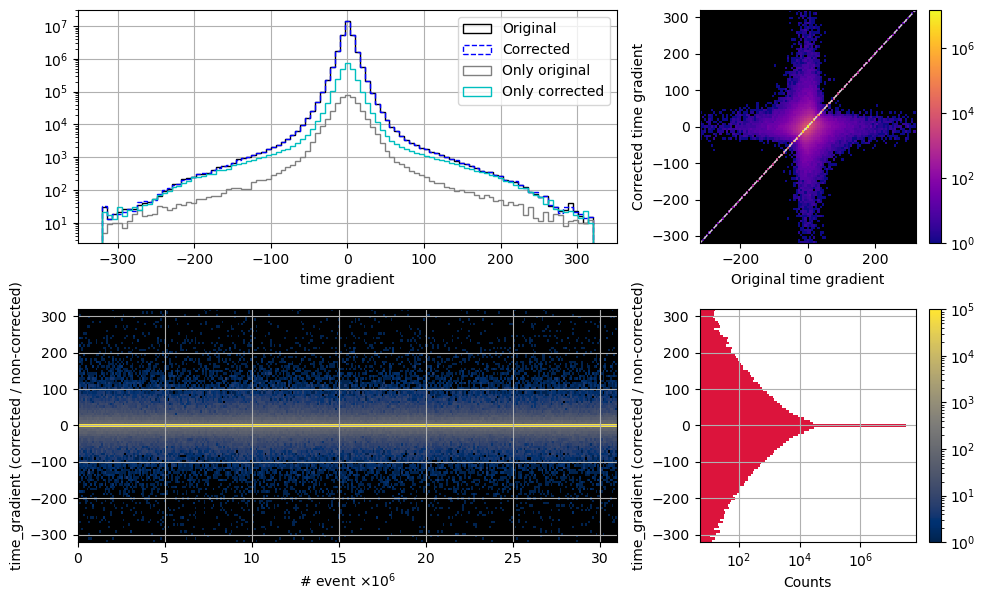

In [17]:
print("event_type == 32 & gammaness > 0.8")
fig, axs = plt.subplots(2, 2, figsize=(10, 6.1), gridspec_kw={"width_ratios": [2, 1]})

key = "time_gradient"
axs[0,0].hist(data_dict[key][2], bins=dict_hist[key]["bins"], 
         color="k", label="Original", histtype="step")
axs[0,0].hist(data_dict[key][3], bins=dict_hist[key]["bins"], 
         color="b", ls="--", label="Corrected", histtype="step")
axs[0,0].hist(data_dict[key][0], bins=dict_hist[key]["bins"], 
         color="grey", histtype="step", label="Only original")
axs[0,0].hist(data_dict[key][1], bins=dict_hist[key]["bins"], 
         color="c", histtype="step", label="Only corrected")

histR = axs[0,1].hist2d(data_dict[key][2], data_dict[key][3], bins=dict_hist[key]["bins"], 
                  norm=LogNorm(), cmap="plasma")
fig.colorbar(histR[3], ax=axs[0,1], label="")

histE = axs[1,0].hist2d(event_array[2] * 1e-6, (data_dict[key][3] - data_dict[key][2]), 
         bins=(300, np.linspace(-320, 320, 100)), norm=LogNorm(), cmap="cividis")
fig.colorbar(histE[3], ax=axs[1,1], label="")
axs[1,1].hist((data_dict[key][3] - data_dict[key][2]), orientation="horizontal",
         bins=np.linspace(-320, 320, 100), histtype="stepfilled", color="crimson")

axs[0,1].plot([-1e10, 1e10], [-1e10, 1e10], ls="--", lw=1, c="lightgray")

axs[0,0].set_yscale("log")
for ax in axs[1]:
    ax.grid(); ax.set_ylim(-320, 320); ax.set_ylabel("time_gradient (corrected / non-corrected)")
    
axs[0,0].set_xlabel("time gradient"); axs[0,0].legend(loc=1); axs[0,0].grid()
axs[0,1].set_xlabel("Original time gradient"); axs[0,1].set_ylabel("Corrected time gradient")
axs[0,1].set_facecolor("k"); axs[1,0].set_facecolor("k"); axs[1,1].set_xscale("log")
axs[1,0].set_xlabel("# event $\\times 10^6$"); axs[1,1].set_xlabel("Counts")
fig.tight_layout()

plt.savefig(root + f"plots/plot_comparison_time_gradient_{source_name}.png", bbox_inches="tight", dpi=300)
plt.show()

event_type == 32 & gammaness > 0.8


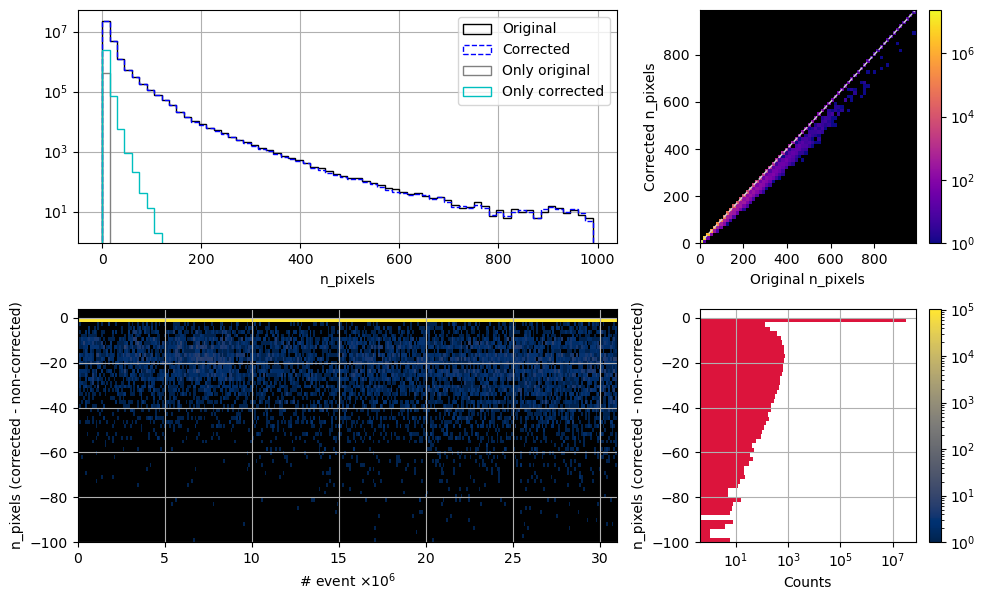

In [18]:
print("event_type == 32 & gammaness > 0.8")
fig, axs = plt.subplots(2, 2, figsize=(10, 6.1), gridspec_kw={"width_ratios": [2, 1]})

key = "n_pixels"
axs[0,0].hist(data_dict[key][2], bins=dict_hist[key]["bins"], 
         color="k", label="Original", histtype="step")
axs[0,0].hist(data_dict[key][3], bins=dict_hist[key]["bins"], 
         color="b", ls="--", label="Corrected", histtype="step")
axs[0,0].hist(data_dict[key][0], bins=dict_hist[key]["bins"], 
         color="grey", histtype="step", label="Only original")
axs[0,0].hist(data_dict[key][1], bins=dict_hist[key]["bins"], 
         color="c", histtype="step", label="Only corrected")

histR = axs[0,1].hist2d(data_dict[key][2], data_dict[key][3], bins=dict_hist[key]["bins"], 
                  norm=LogNorm(), cmap="plasma")
fig.colorbar(histR[3], ax=axs[0,1], label="")

histE = axs[1,0].hist2d(event_array[2] * 1e-6, (data_dict[key][3] - data_dict[key][2]), 
         bins=(300, 100), norm=LogNorm(), cmap="cividis")
fig.colorbar(histE[3], ax=axs[1,1], label="")
axs[1,1].hist((data_dict[key][3] - data_dict[key][2]), orientation="horizontal",
         bins=np.arange(-100, 2, 2), histtype="stepfilled", color="crimson")

axs[0,1].plot([-1e10, 1e10], [-1e10, 1e10], ls="--", lw=1, c="lightgray")

axs[0,0].set_yscale("log")
for ax in axs[1]:
    ax.grid(); ax.set_ylim(-100, 4); ax.set_ylabel("n_pixels (corrected - non-corrected)")
    
axs[0,0].set_xlabel("n_pixels"); axs[0,0].legend(loc=1); axs[0,0].grid()
axs[0,1].set_xlabel("Original n_pixels"); axs[0,1].set_ylabel("Corrected n_pixels")
axs[0,1].set_facecolor("k"); axs[1,0].set_facecolor("k"); axs[1,1].set_xscale("log")
axs[1,0].set_xlabel("# event $\\times 10^6$"); axs[1,1].set_xlabel("Counts")
fig.tight_layout()

plt.savefig(root + f"plots/plot_comparison_n_pixels_{source_name}.png", bbox_inches="tight", dpi=300)
plt.show()

event_type == 32 & gammaness > 0.8


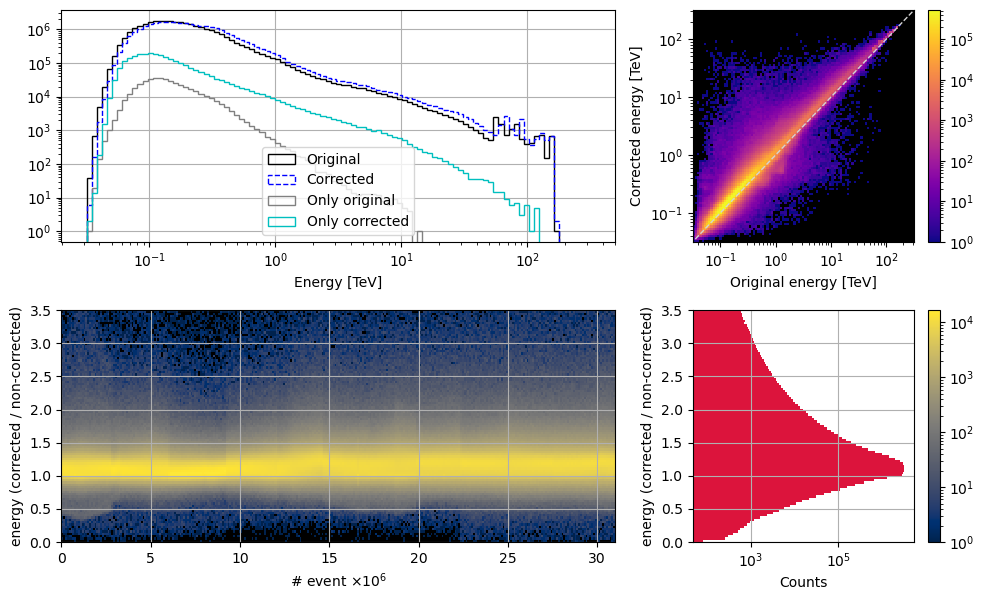

In [19]:
print("event_type == 32 & gammaness > 0.8")
fig, axs = plt.subplots(2, 2, figsize=(10, 6.1), gridspec_kw={"width_ratios": [2, 1]})

key = "reco_energy"
axs[0,0].hist(data_dict[key][2], bins=dict_hist[key]["bins"], 
         color="k", label="Original", histtype="step")
axs[0,0].hist(data_dict[key][3], bins=dict_hist[key]["bins"], 
         color="b", ls="--", label="Corrected", histtype="step")
axs[0,0].hist(data_dict[key][0], bins=dict_hist[key]["bins"], 
         color="grey", histtype="step", label="Only original")
axs[0,0].hist(data_dict[key][1], bins=dict_hist[key]["bins"], 
         color="c", histtype="step", label="Only corrected")

histR = axs[0,1].hist2d(data_dict[key][2], data_dict[key][3], bins=dict_hist[key]["bins"], 
                  norm=LogNorm(), cmap="plasma")
fig.colorbar(histR[3], ax=axs[0,1], label="")

histE = axs[1,0].hist2d(event_array[2] * 1e-6, (data_dict[key][3] / data_dict[key][2]), 
         bins=(300, np.linspace(0, 3.5, 100)), norm=LogNorm(), cmap="cividis")
fig.colorbar(histE[3], ax=axs[1,1], label="")
axs[1,1].hist((data_dict[key][3] / data_dict[key][2]), orientation="horizontal",
         bins=np.linspace(0, 3.5, 100), histtype="stepfilled", color="crimson")

axs[0,1].plot([-1e10, 1e10], [-1e10, 1e10], ls="--", lw=1, c="lightgray")

for ax in axs[0]:
    ax.loglog()
for ax in axs[1]:
    ax.grid(); ax.set_ylim(0, 3.5); ax.set_ylabel("energy (corrected / non-corrected)")
    
axs[0,0].set_xlabel("Energy [TeV]"); axs[0,0].legend(loc=8); axs[0,0].grid()
axs[0,1].set_xlabel("Original energy [TeV]"); axs[0,1].set_ylabel("Corrected energy [TeV]")
axs[0,1].set_facecolor("k"); axs[1,0].set_facecolor("k"); axs[1,1].set_xscale("log")
axs[1,0].set_xlabel("# event $\\times 10^6$"); axs[1,1].set_xlabel("Counts")
fig.tight_layout()

plt.savefig(root + f"plots/plot_comparison_energy_{source_name}.png", bbox_inches="tight", dpi=300)
plt.show()

event_type == 32 & gammaness > 0.8


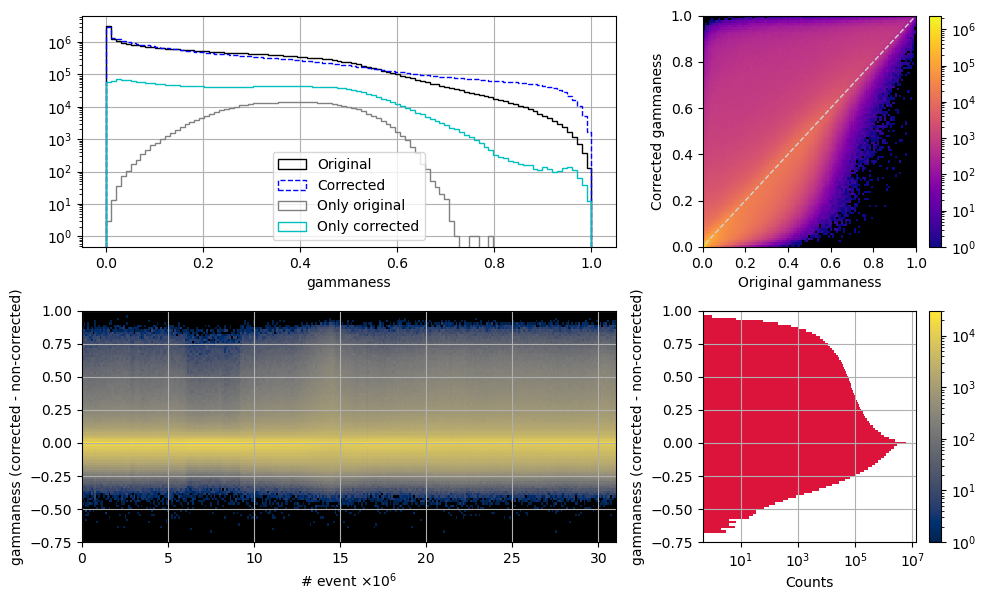

In [20]:
print("event_type == 32 & gammaness > 0.8")
fig, axs = plt.subplots(2, 2, figsize=(10, 6.1), gridspec_kw={"width_ratios": [2, 1]})

key = "gammaness"
axs[0,0].hist(data_dict[key][2], bins=dict_hist[key]["bins"], 
         color="k", label="Original", histtype="step")
axs[0,0].hist(data_dict[key][3], bins=dict_hist[key]["bins"], 
         color="b", ls="--", label="Corrected", histtype="step")
axs[0,0].hist(data_dict[key][0], bins=dict_hist[key]["bins"], 
         color="grey", histtype="step", label="Only original")
axs[0,0].hist(data_dict[key][1], bins=dict_hist[key]["bins"], 
         color="c", histtype="step", label="Only corrected")

histR = axs[0,1].hist2d(data_dict[key][2], data_dict[key][3], bins=dict_hist[key]["bins"], 
                  norm=LogNorm(), cmap="plasma")
fig.colorbar(histR[3], ax=axs[0,1], label="")

histE = axs[1,0].hist2d(event_array[2] * 1e-6, (data_dict[key][3] - data_dict[key][2]), 
         bins=(300, np.linspace(-0.75, 1, 100)), norm=LogNorm(), cmap="cividis")
fig.colorbar(histE[3], ax=axs[1,1], label="")
axs[1,1].hist((data_dict[key][3] - data_dict[key][2]), orientation="horizontal",
         bins=np.linspace(-0.75, 1, 100), histtype="stepfilled", color="crimson")

axs[0,1].plot([-1e10, 1e10], [-1e10, 1e10], ls="--", lw=1, c="lightgray")

axs[0,0].set_yscale("log")
for ax in axs[1]:
    ax.grid(); ax.set_ylim(-0.75, 1); ax.set_ylabel("gammaness (corrected - non-corrected)")
    
axs[0,0].set_xlabel("gammaness"); axs[0,0].legend(loc=8); axs[0,0].grid()
axs[0,1].set_xlabel("Original gammaness"); axs[0,1].set_ylabel("Corrected gammaness")
axs[0,1].set_facecolor("k"); axs[1,0].set_facecolor("k"); axs[1,1].set_xscale("log")
axs[1,0].set_xlabel("# event $\\times 10^6$"); axs[1,1].set_xlabel("Counts")
fig.tight_layout()

plt.savefig(root + f"plots/plot_comparison_gammaness_{source_name}.png", bbox_inches="tight", dpi=300)
plt.show()